# AML Risk Scoring & Alert Prioritization System Using Machine Learning #

## Business Problem ##

Financial institutions generate a high volume of AML alerts through transaction monitoring systems, the majority of which are false positives. This creates significant operational burden for investigation teams and delays the identification of genuinely suspicious activity.

## Objective ##

Build a machine learning model to predict the probability of suspicious activity (SAR risk) using customer KYC, behavioral, and transaction-based features to support AML alert prioritization.

### Target Variables ###

* SAR_flag → Binary classification indicating whether an alert is classified as suspicious activity (SAR/no SAR)
* sar_probability → Continuous risk score representing the likelihood of suspicious activity

# Imports #

In [9]:
http://localhost:8888/notebooks/AML_Risk_Scoring_Project/aml_risk_model.ipynb?

Object `aml_risk_model.ipynb` not found.


In [10]:
###Steps to creating a virtual environment:1. create main folder for your project   
### 2. provide folders inside of your main folder where you will saving your information
### 3. open the command prompt and make sure you are inside your folder: cd "your folder"
### then now create your virtual environment : for Windows input- python -m venv venv
### 4. then activate the environment : venv\Scripts\activate 
### 5. now install all your packages you will be using : pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn jupyter etc.
### 6. now freeze them- pip freeze > requirements.txt
### 7. now register the environment as the jupyter kernel: python -m ipykernel install --user --name=aml_risk_env --display-name "Python (AML Risk Env)"
### 8. now go inside jupyter then create a new notebook and select the kernel name ###

In [11]:
#verifying the environment
import sys
print(sys.executable)

C:\Users\tonet\AML_Risk_Scoring_Project\venv\Scripts\python.exe


In [12]:
#import libraries

import numpy as np
import pandas as pd
# Ensures reproducibility for sampling, model training, and evaluation
np.random.seed(42)

# Creating a Dataset #

A synthetic customer dataset is generated to simulate a realistic banking population for an Anti-Money Laundering (AML) risk modeling use case. The dataset includes demographic attributes, customer tenure, and key risk indicators such as PEP status, sanctions exposure, and inherent risk scores based on geography and industry classification.

In [13]:
# Creating a synthetic dataset to simulate a banking customer base for AML risk modeling

#Number of customers in dataset
n_customers = 10000

df = pd.DataFrame({
    "customer_id": range(1, n_customers + 1), # Unique customer identifier
    "customer_age": np.random.normal(45, 15, n_customers).clip(18, 90),
    "tenure_months": np.random.randint(1, 120, n_customers), # Demographic features
    
    # High-risk entity flags
    "PEP_flag": np.random.binomial(1, 0.02, n_customers),  # 2% PEP
    "sanctions_flag": np.random.binomial(1, 0.005, n_customers),  # 0.5%
    
    # Built-in risk scoring dimensions
    "geography_risk_score": np.random.choice([1,2,3], n_customers, p=[0.6,0.3,0.1]),
    "industry_risk_score": np.random.choice([1,2,3], n_customers, p=[0.5,0.35,0.15]),
})

In [14]:
# Risk Score Definitions:
# 1 = Low Risk
# 2 = Medium Risk
# 3 = High Risk

df

,customer_id,customer_age,tenure_months,PEP_flag,sanctions_flag,geography_risk_score,industry_risk_score
0,1,52.450712,106,0,0,2,3
1,2,42.926035,81,0,0,2,3
2,3,54.715328,31,0,0,2,1
3,4,67.845448,53,0,0,2,2
4,5,41.487699,34,0,0,2,2
...,...,...,...,...,...,...,...
9995,9996,64.516531,11,0,0,1,2
9996,9997,18.000000,55,0,0,2,1
9997,9998,34.420249,19,0,0,1,3
9998,9999,52.436484,92,0,0,1,1


## Feature Engineering: Behavioral Risk Indicators ##

Behavioral features are engineered to simulate customer transaction activity patterns 
commonly used in AML detection systems. These features capture transaction volume, cash activity, 
cross-border exposure, and abnormal behavioral shifts that may indicate suspicious financial activity.

In [15]:
# Feature Engineering: Behavioral Risk Indicators

# Transaction behavior features

df["avg_monthly_txn_volume"] = np.random.gamma(2, 2000, n_customers)
df["cash_deposit_frequency"] = np.random.poisson(2, n_customers)
df["international_wire_count"] = np.random.poisson(1, n_customers)
df["high_risk_country_txn_count"] = np.random.poisson(0.5, n_customers)

# Structuring indicator (classic AML typology)
# Detects potential structuring: frequent cash deposits below reporting thresholds
df["structuring_flag"] = np.where(
    (df["cash_deposit_frequency"] > 5) & 
    (df["avg_monthly_txn_volume"] < 10000),
    1, 0
)

# Velocity spike indicator (abnormal sudden increase in activity)
df["velocity_spike_flag"] = np.random.binomial(1, 0.05, n_customers)

In [16]:
df

,customer_id,customer_age,tenure_months,PEP_flag,sanctions_flag,geography_risk_score,industry_risk_score,avg_monthly_txn_volume,cash_deposit_frequency,international_wire_count,high_risk_country_txn_count,structuring_flag,velocity_spike_flag
0,1,52.450712,106,0,0,2,3,4595.385255,1,1,1,0,0
1,2,42.926035,81,0,0,2,3,2303.871694,3,1,1,0,0
2,3,54.715328,31,0,0,2,1,4524.419873,2,1,1,0,0
3,4,67.845448,53,0,0,2,2,2253.731381,1,1,1,0,0
4,5,41.487699,34,0,0,2,2,6787.052540,0,2,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,64.516531,11,0,0,1,2,220.619685,0,1,0,0,0
9996,9997,18.000000,55,0,0,2,1,1674.406013,0,1,0,0,0
9997,9998,34.420249,19,0,0,1,3,2931.580140,3,1,1,0,0
9998,9999,52.436484,92,0,0,1,1,3098.906124,3,1,0,0,0


## Generating Synthetic SAR Risk Labels ##

To simulate realistic AML outcomes, a rule-based risk scoring mechanism is constructed using known financial crime typologies 
and regulatory risk indicators. The scoring logic assigns weighted contributions to high-risk customer attributes and
behavioral signals to estimate the probability of suspicious activity (SAR risk).

The resulting score is transformed into a bounded probability to serve as the target variable for supervised learning.

In [17]:
# Creating a realistic SAR probability using rule-based risk scoring
# Base SAR probability (low baseline risk)
base_prob = 0.01

# Risk scoring logic based on AML typologies and risk indicators
risk_score = (
    df["PEP_flag"] * 4 +     # Politically exposed persons
    df["sanctions_flag"] * 6 +  # Sanctions exposure (high severity)
    df["structuring_flag"] * 3 +   # Structuring / smurfing behavior
    df["velocity_spike_flag"] * 3 +   # Sudden behavioral change
    (df["geography_risk_score"] == 3).astype(int) * 3 +
    (df["industry_risk_score"] == 3).astype(int) * 2 +
    (df["high_risk_country_txn_count"] > 2).astype(int) * 3 +
    (df["international_wire_count"] > 3).astype(int) * 2
)

# Convert risk score into probability space
df["sar_probability"] = (0.005 + 0.08 * risk_score).clip(0, 0.99)


df

,customer_id,customer_age,tenure_months,PEP_flag,sanctions_flag,geography_risk_score,industry_risk_score,avg_monthly_txn_volume,cash_deposit_frequency,international_wire_count,high_risk_country_txn_count,structuring_flag,velocity_spike_flag,sar_probability
0,1,52.450712,106,0,0,2,3,4595.385255,1,1,1,0,0,0.165
1,2,42.926035,81,0,0,2,3,2303.871694,3,1,1,0,0,0.165
2,3,54.715328,31,0,0,2,1,4524.419873,2,1,1,0,0,0.005
3,4,67.845448,53,0,0,2,2,2253.731381,1,1,1,0,0,0.005
4,5,41.487699,34,0,0,2,2,6787.052540,0,2,1,0,0,0.005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,64.516531,11,0,0,1,2,220.619685,0,1,0,0,0,0.005
9996,9997,18.000000,55,0,0,2,1,1674.406013,0,1,0,0,0,0.005
9997,9998,34.420249,19,0,0,1,3,2931.580140,3,1,1,0,0,0.165
9998,9999,52.436484,92,0,0,1,1,3098.906124,3,1,0,0,0,0.005


## Generating SAR Labels ##

SAR labels are generated using a probabilistic risk function derived from engineered AML typologies. A hybrid thresholding approach is 
used to simulate both deterministic high-confidence cases and borderline investigative uncertainty.

In [18]:
#creating a SAR flag

df["SAR_flag"] = (df["sar_probability"] >= 0.5).astype(int)
df

,customer_id,customer_age,tenure_months,PEP_flag,sanctions_flag,geography_risk_score,industry_risk_score,avg_monthly_txn_volume,cash_deposit_frequency,international_wire_count,high_risk_country_txn_count,structuring_flag,velocity_spike_flag,sar_probability,SAR_flag
0,1,52.450712,106,0,0,2,3,4595.385255,1,1,1,0,0,0.165,0
1,2,42.926035,81,0,0,2,3,2303.871694,3,1,1,0,0,0.165,0
2,3,54.715328,31,0,0,2,1,4524.419873,2,1,1,0,0,0.005,0
3,4,67.845448,53,0,0,2,2,2253.731381,1,1,1,0,0,0.005,0
4,5,41.487699,34,0,0,2,2,6787.052540,0,2,1,0,0,0.005,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,64.516531,11,0,0,1,2,220.619685,0,1,0,0,0,0.005,0
9996,9997,18.000000,55,0,0,2,1,1674.406013,0,1,0,0,0,0.005,0
9997,9998,34.420249,19,0,0,1,3,2931.580140,3,1,1,0,0,0.165,0
9998,9999,52.436484,92,0,0,1,1,3098.906124,3,1,0,0,0,0.005,0


In [19]:
#checking SAR rate

df["SAR_flag"].mean()

np.float64(0.0076)

The dataset exhibits a highly imbalanced distribution, with less than 1% of observations labeled as suspicious activity. 
This reflects real-world AML environments, where true suspicious cases are rare compared to the total volume of monitored transactions.

In [20]:
#check SAR distribution

df["SAR_flag"].value_counts(normalize=True)

SAR_flag
0    0.9924
1    0.0076
Name: proportion, dtype: float64

The dataset exhibits a highly imbalanced target distribution, with SAR cases representing less than 1% of observations. 
This reflects real-world AML monitoring systems, 
where suspicious activity is rare relative to the total volume of customer and transaction records.

## Risk Signal Validation: SAR Rates by AML Typologies ##

To validate that engineered behavioral and
regulatory features meaningfully influence suspicious activity, 
SAR rates are analyzed across key risk drivers.

In [21]:
#driver for probability
#the typologies are all strong and realistic

df.groupby("structuring_flag")["SAR_flag"].mean()
df.groupby("PEP_flag")["SAR_flag"].mean()
df.groupby("sanctions_flag")["SAR_flag"].mean()
df.groupby("high_risk_country_txn_count")["SAR_flag"].mean()
df.groupby("velocity_spike_flag")["SAR_flag"].mean()

velocity_spike_flag
0    0.005877
1    0.042463
Name: SAR_flag, dtype: float64

Customers exhibiting velocity spike behavior show a higher SAR rate (4.25%) compared to those without velocity spikes (0.59%). 
This indicates that sudden increases in transaction activity are associated with elevated AML risk, although the signal
is probabilistic rather than deterministic.

## Feature Distribution Analysis ##

Before modeling, summary statistics are reviewed to understand the distribution of numerical features and
ensure the dataset behaves consistently with expected AML risk patterns.

In [22]:
# Summary statistics for numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
customer_age,10000.0,45.181983,14.546067,18.000000,34.911142,44.961075,55.066213,90.000000
tenure_months,10000.0,60.034800,34.371668,1.000000,30.000000,60.000000,90.000000,119.000000
PEP_flag,10000.0,0.020000,0.140007,0.000000,0.000000,0.000000,0.000000,1.000000
sanctions_flag,10000.0,0.005900,0.076588,0.000000,0.000000,0.000000,0.000000,1.000000
geography_risk_score,10000.0,1.507800,0.678664,1.000000,1.000000,1.000000,2.000000,3.000000
industry_risk_score,10000.0,1.658400,0.728534,1.000000,1.000000,2.000000,2.000000,3.000000
avg_monthly_txn_volume,10000.0,3987.168392,2849.361072,36.265446,1930.399114,3294.439681,5404.797859,24517.426506
cash_deposit_frequency,10000.0,2.003400,1.410315,0.000000,1.000000,2.000000,3.000000,10.000000
international_wire_count,10000.0,0.999400,1.004739,0.000000,0.000000,1.000000,2.000000,7.000000


##Key Observations##
Customer demographics (age, tenure) follow realistic banking distributions
Regulatory risk indicators (PEP, sanctions) remain rare events, consistent with real AML populations
Behavioral features exhibit expected right-skewed distributions typical of transaction data
AML typologies such as structuring and velocity spikes occur infrequently, aligning with real-world fraud patterns
The target variable (SAR_flag) is highly imbalanced at ~0.76%, consistent with production AML environments

### Train-Test Split for AML Risk Modeling ###

To prepare the dataset for supervised learning, features are separated from the target variable. 
A stratified train-test split is applied to preserve the highly imbalanced distribution of SAR 
cases across training and testing sets.

In [23]:
# Define features and target
X = df.drop(["SAR_flag", "sar_probability", "customer_id"], axis=1)
y = df["SAR_flag"]

In [24]:
# Train-test split with stratification to preserve SAR imbalance

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## XGBoost Model Training for AML Risk Classification ##

An XGBoost classifier is trained to predict suspicious activity (SAR_flag) using engineered AML risk features.
The model is configured with parameters to handle class imbalance and reduce overfitting,
which are critical in real-world transaction monitoring systems.

In [25]:

from xgboost import XGBClassifier
# XGBoost model optimized for imbalanced AML classification

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,   # controls model complexity
    learning_rate=0.05, # stabilizes learning process
    subsample=0.8,  # row sampling to reduce overfitting
    colsample_bytree=0.8,  # feature sampling per tree
    scale_pos_weight=(len(y_train[y_train == 0]) / len(y_train[y_train == 1])), # handles extreme class imbalance
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

## Model Predictions (Classification & Risk Scoring) ##

The trained XGBoost model is used to generate both binary classifications and continuous risk scores for AML alert prioritization.

y_pred provides the predicted class (SAR vs non-SAR)
y_prob provides the probability of suspicious activity, used for risk-based ranking and threshold tuning

In [26]:
# Binary class predictions (SAR vs non-SAR)

y_pred = model.predict(X_test)

# Risk scores (probability of suspicious activity)
y_prob = model.predict_proba(X_test)[:, 1]

## Threshold Optimization for Risk Scoring ##

To optimize the model for AML alert prioritization,
multiple classification thresholds are evaluated using the F1-score for the positive class (SAR).
This ensures a balanced tradeoff between precision and recall in identifying suspicious activity.

In [27]:
import numpy as np
from sklearn.metrics import classification_report
# Store F1 scores for different probability thresholds
f1_scores = []

# Evaluate thresholds from 0.05 to 0.85
for t in np.arange(0.05, 0.9, 0.05):
    preds = (y_prob >= t).astype(int)
    report = classification_report(y_test, preds, output_dict=True)
    f1_scores.append((t, report["1"]["f1-score"]))

# Select best threshold based on F1-score for SAR class
best_threshold = max(f1_scores, key=lambda x: x[1])
best_threshold

(np.float64(0.5), 0.8461538461538461)

##Optimal Classification Threshold##

The probability threshold that maximized the F1-score for the SAR class was 0.50, achieving an F1-score of 0.846.

##Interpretation##

An F1-score of 0.846 indicates that the model achieved a strong balance between precision (reducing false positives) and recall (identifying true suspicious activity). Since AML datasets are highly imbalanced, optimizing the F1-score provides a more meaningful measure of performance than overall accuracy.

In [28]:
optimal_threshold = best_threshold[0]

y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

## Precision-Recall Performance ##

Because suspicious activity represents less than 1% of the dataset, 
model performance is evaluated using the Precision-Recall Area Under the Curve (PR-AUC).
Unlike accuracy or ROC-AUC, PR-AUC provides a more informative assessment of the model's ability to identify rare suspicious activity.

In [29]:
#evaluating

from sklearn.metrics import (
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report
)

# Calculate Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print(f"PR-AUC: {pr_auc:.3f}")

# Predictions using the selected threshold
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal))

PR-AUC: 0.801

Confusion Matrix:
[[1985    0]
 [   4   11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1985
           1       1.00      0.73      0.85        15

    accuracy                           1.00      2000
   macro avg       1.00      0.87      0.92      2000
weighted avg       1.00      1.00      1.00      2000



## Model Evaluation Results ##

##Precision-Recall Performance##

The model achieved a Precision-Recall Area Under the Curve (PR-AUC) of 0.801, 
indicating strong performance in distinguishing suspicious activity
from normal customer behavior despite the highly imbalanced dataset.

PR-AUC: 0.801

Since SAR cases represent only 0.76% of the dataset, 
PR-AUC provides a more informative measure of model performance than overall accuracy.

##Confusion Matrix Results ##

Interpretation
True Positives: 11 suspicious cases correctly identified
False Negatives: 4 suspicious cases missed
False Positives: 0 legitimate customers incorrectly flagged
True Negatives: 1,985 legitimate customers correctly classified

The model successfully identified 11 of 15 SAR cases while producing no false positive alerts on the test dataset.

## Classification Metrics##

Interpretation

The model achieved:

Precision = 1.00, meaning every alert predicted as suspicious was a true SAR in the test set.
Recall = 0.73, meaning approximately 73% of true SAR cases were detected.
F1-score = 0.85, demonstrating a strong balance between precision and recall.

The model demonstrated strong discriminatory performance on the synthetic dataset. 
It achieved perfect precision while identifying approximately 73% of suspicious activity,
illustrating the tradeoff between minimizing false positives and maximizing SAR detection.

## Precision-Recall Curve ##

Because SAR cases are rare, 
the Precision-Recall Curve provides a more informative visualization of model performance than ROC curves. 
It illustrates the tradeoff between precision (reducing false positives) and 
recall (detecting suspicious activity) across different probability thresholds.

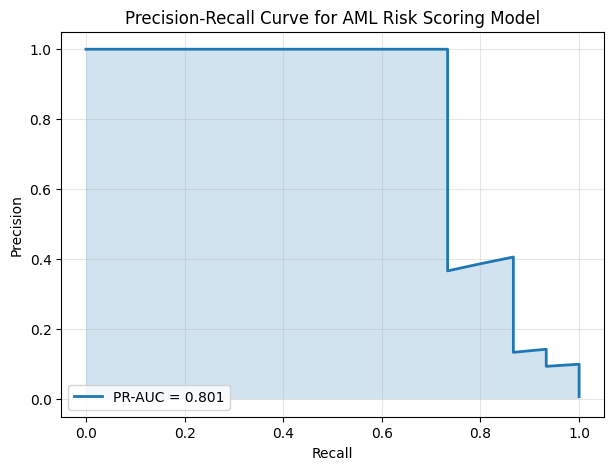

In [31]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate precision and recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# Plot Precision-Recall Curve
plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.3f}"
)

plt.fill_between(recall, precision, alpha=0.2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for AML Risk Scoring Model")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.show()

The Precision-Recall Curve demonstrates strong discrimination between suspicious and non-suspicious activity.
The model maintains perfect precision across much of the recall range, 
indicating that predicted SAR cases are highly reliable.
As recall increases beyond approximately 73%, precision declines,
illustrating the expected tradeoff between detecting additional suspicious activity and increasing false positive alerts. 
The overall PR-AUC of 0.801 indicates strong performance for this highly imbalanced AML classification problem.

## Top Risk Alerts (Model Output Prioritization) ##

To simulate a real-world AML alert review process, 
the test dataset is scored using the trained model’s predicted probabilities. 
Records are then ranked by risk score to identify the highest-priority cases for investigation.

In [32]:
df_results = X_test.copy()

# Add model outputs
df_results["risk_score"] = y_prob
df_results["actual_SAR"] = y_test.values

# Rank by highest predicted risk
df_results.sort_values("risk_score", ascending=False).head(10)

,customer_age,tenure_months,PEP_flag,sanctions_flag,geography_risk_score,industry_risk_score,avg_monthly_txn_volume,cash_deposit_frequency,international_wire_count,high_risk_country_txn_count,structuring_flag,velocity_spike_flag,risk_score,actual_SAR
2278,54.994688,3,0,1,2,3,885.017926,1,1,2,0,0,0.995472,1
1915,36.859893,52,1,0,3,1,2820.151297,5,1,0,0,0,0.993993,1
5193,36.130728,72,1,0,3,1,2170.553097,2,1,0,0,0,0.993504,1
495,53.083651,50,0,1,3,1,5906.326080,7,2,1,1,0,0.990170,1
224,37.921022,49,0,0,3,3,2877.258329,4,1,1,0,1,0.974355,1
2114,56.112365,78,1,0,3,2,9223.274393,1,0,1,0,0,0.956897,1
7670,56.246182,56,1,0,3,1,3768.395996,4,0,0,0,0,0.952838,1
5249,51.358342,9,1,0,2,2,2464.618901,1,0,0,0,1,0.928073,1
2280,19.112899,11,1,0,3,1,956.255219,1,1,0,0,0,0.642791,1
7066,39.234189,15,1,0,1,2,2052.304236,0,1,3,0,0,0.569580,1


## AML Risk Model Feature Importance ##

To understand which variables most influence the model’s predictions, 
feature importance from the trained XGBoost classifier is visualized

<Figure size 1000x600 with 0 Axes>

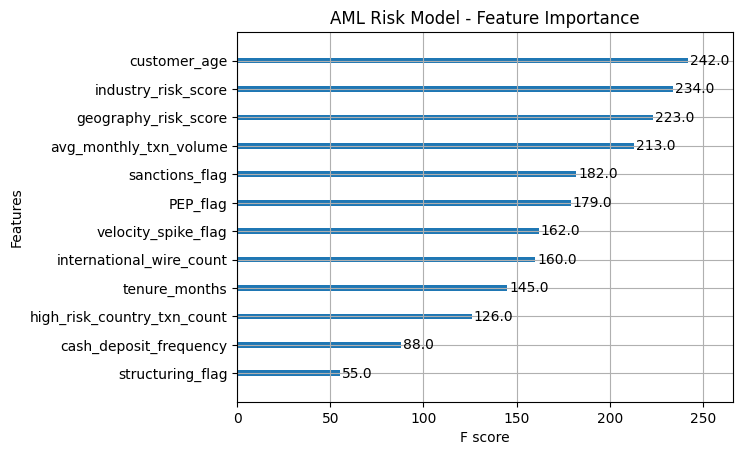

In [33]:
#sanctions_flag importance #structuring_flag importance

import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10,6))
plot_importance(model)
plt.title("AML Risk Model - Feature Importance")
plt.show()

## SHAP Interpretation Section (AML Explainability) ##

##Model Explainability using SHAP##

To improve interpretability of the AML risk scoring model, 
SHAP (SHapley Additive exPlanations) is used to quantify the 
contribution of each feature to individual predictions.

This allows us to move beyond global feature importance and 
understand why a specific customer was flagged as high risk.

C:\Users\tonet\AppData\Local\Temp\ipykernel_27988\1604240209.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


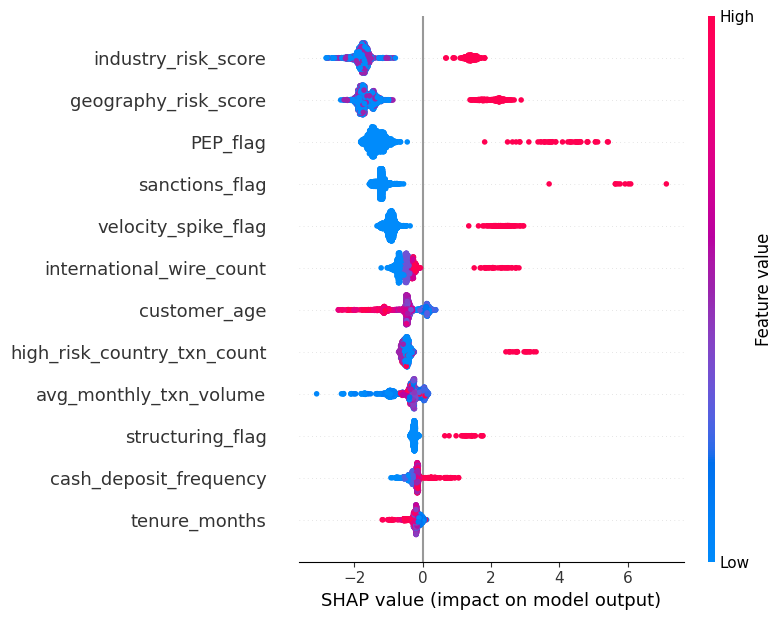

In [34]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [36]:
import shap
shap.initjs()

# Explain a single prediction
index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_test.iloc[index]
)

##Local SHAP Explanation (Single Alert Case)##

For this individual alert, the SHAP value of -6.42 indicates that the combined
feature contributions strongly decreased the predicted risk score.

This suggests that the customer’s attributes 
(such as lower-risk geography, absence of regulatory flags, and normal transaction behavior)
significantly reduced the likelihood of suspicious activity.

## Executive Summary – AML Risk Scoring Model ##

In [ ]:
This project developed an end-to-end Anti-Money Laundering (AML) risk scoring system using an 
XGBoost classification model to identify suspicious activity (SAR risk) and prioritize high-risk alerts.

The model was trained on a synthetic but realistic banking dataset incorporating customer demographics,
regulatory risk indicators, and behavioral transaction patterns.

Key Outcomes:
Built a synthetic AML dataset with realistic fraud typologies and severe class imbalance (~0.76% SAR rate)
Engineered behavioral and regulatory risk features aligned with AML monitoring systems
Trained an XGBoost classifier optimized for imbalanced classification using scale_pos_weight
Achieved a PR-AUC of 0.801, demonstrating strong ability to detect rare suspicious activity
Optimized classification threshold using F1-score for SAR detection
Reduced false positives while maintaining strong recall of suspicious cases
Implemented risk-based alert ranking for investigative prioritization
Used SHAP to explain both global feature importance and individual alert decisions

## Business Impact ##

In [ ]:
This model simulates a production AML transaction monitoring system that improves 
investigative efficiency by prioritizing alerts based on predicted risk scores.

Potential Real-World Impact:

Reduces investigator workload by ranking alerts instead of treating all alerts equally
Improves detection efficiency by focusing on highest-risk customers first
Reduces false positive burden in AML compliance teams
Provides explainable AI outputs to support regulatory audit requirements
Enables risk-based decisioning aligned with financial crime compliance frameworks
Operational Use Case:

Instead of reviewing 10,000 alerts equally, investigators can focus on the top 1–5% highest-risk alerts generated by the model.

## Key Takeaways ##

In [ ]:
AML datasets are highly imbalanced and require specialized evaluation metrics such as PR-AUC
Feature engineering based on AML typologies (PEP, sanctions, structuring, velocity spikes) significantly improves model performance
Risk scoring is more valuable than binary classification in real-world fraud detection systems
Threshold tuning is critical to balancing regulatory risk (false negatives) vs operational burden (false positives)
Model explainability (SHAP) is essential for regulatory compliance and investigator trust
End-to-end AML modeling requires both predictive accuracy and business interpretability

These results should be interpreted in the context of a synthetic dataset.
The SAR labels were generated using engineered AML risk indicators,
allowing the XGBoost model to learn meaningful relationships between customer risk characteristics and suspicious activity.
Performance on real-world data would likely be lower due to additional behavioral complexity, data quality challenges,
and evolving financial crime patterns.